In [15]:
## script for processing obstacle avoidance session 
## Notes: 8/23/22(Works with ephys0 enviroment)
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
import glob
import h5py
import subprocess

from scipy.ndimage import gaussian_filter1d
from datetime import datetime


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from pipeline.obstacle_avoidance_with_cam import AvoidanceSession

from src.base import BaseInput

from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from src.utils.path import find
#from utils.base_functions import *
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays
from pipeline.oa_with_cams_plotting_funcs import *
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,deveation,lateral_error,df_tortuosity,head_angle_velocity,start
#from plots.plots import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [16]:
df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\041825\F3LILT\oa_cam\odd_even_F3LILT_041825_oa.h5")

key

In [22]:
row[key]

array([55305, 55306, 55307, ..., 56598, 56599, 56600], dtype=object)

In [21]:
row[key][0][odd_ind:]

TypeError: 'int' object is not subscriptable

In [23]:
row[key]

array([55305, 55306, 55307, ..., 56598, 56599, 56600], dtype=object)

row[key][0][odd_ind:]

In [19]:
keys = ['head_cen','leftear','rightear','spine','midspine','tailbase','trial_timestamps','trial_vidframes']
keys_list = list_columns(df,keys)
keys_list= [col for col in keys_list if 'likelihood' not in col]
keys_list= [col for col in keys_list if 'lind' not in col]
# check if odd or even trial
#  get first index when nose crosses a distance thresh hold
#trail start = ts
##odd tiral at 16 cm even at 56 cm     
for ind, row in df.iterrows(): 
    if row['odd'] == 'left':
        nose_list = row['head_cen_x_cm'] 
        odd_ind = np.argmax(nose_list>(df.leftspout_x_cm.unique()+5))
        for key in keys_list:
            if key == 'trial_vidframes':
                df.at[ind,'ts_' + key] = row[key][0][odd_ind:]
            else:
                df.at[ind,'ts_' + key] = row[key][odd_ind:]
    
        #use odd_ind to index into obstacle 
        # iterate over columns list 
        #create gt_obstacle points
    else: 
        nose_list = row['head_cen_x_cm']
        even_ind = np.argmax(nose_list<(df.rightspout_x_cm.unique()-5))
        for key in keys_list:
            df.at[ind,'ts_' + key] = row[key][even_ind:] 

TypeError: 'int' object is not subscriptable

In [121]:
keys = ['head_cen','leftear','rightear','spine','midspine','tailbase','trial_timestamps','trial_vidframes']
keys_list = list_columns(df,keys)
keys_list= [col for col in keys_list if 'likelihood' not in col]
keys_list= [col for col in keys_list if 'lind' not in col]
# check if odd or even trial
#  get first index when nose crosses a distance thresh hold
#trail start = ts
##odd tiral at 16 cm even at 56 cm     
for ind, row in df.iterrows(): 
    if row['odd'] == 'left':
        nose_list = row['head_cen_x_cm'] 
        odd_ind = np.argmax(nose_list>(df.leftspout_x_cm.unique()+5))
        for key in keys_list:
            if key == 'trial_vidframes':
                df.at[ind,'ts_' + key] = row[key][0][odd_ind:]
            else:
                df.at[ind,'ts_' + key] = row[key][odd_ind:]
    
        #use odd_ind to index into obstacle 
        # iterate over columns list 
        #create gt_obstacle points
    else: 
        nose_list = row['head_cen_x_cm']
        even_ind = np.argmax(nose_list<(df.rightspout_x_cm.unique()-5))
        for key in keys_list:
            df.at[ind,'ts_' + key] = row[key][even_ind:]

TypeError: 'int' object is not subscriptable

In [123]:
key

'trial_vidframes'

In [126]:
len(row['trial_vidframes'][odd_ind:])

1296

In [ ]:
x_cols_T = ['leftportT_1_x_cm', 'leftportT_2_x_cm', 'leftportT_3_x_cm', 'leftportT_4_x_cm']
y_cols_T = ['leftportT_1_y_cm', 'leftportT_2_y_cm', 'leftportT_3_y_cm', 'leftportT_4_y_cm']

df[x_cols_T] = df[x_cols_T].astype(float)
df[y_cols_T] = df[y_cols_T].astype(float)

df['leftportT_x_cm'] = df[x_cols_T].mean(axis=1, skipna=True)
df['leftportT_y_cm'] = df[y_cols_T].mean(axis=1, skipna=True)


x_cols_B = ['leftportB_1_x_cm', 'leftportB_2_x_cm', 'leftportB_3_x_cm', 'leftportB_4_x_cm']
y_cols_B = ['leftportB_1_y_cm', 'leftportB_2_y_cm', 'leftportB_3_y_cm', 'leftportB_4_y_cm']

df[x_cols_B] = df[x_cols_B].astype(float)
df[y_cols_B] = df[y_cols_B].astype(float)

df['leftportB_x_cm'] = df[x_cols_B].mean(axis=1, skipna=True)
df['leftportB_y_cm'] = df[y_cols_B].mean(axis=1, skipna=True)

In [21]:
x_cols_T = ['rightportT_1_x_cm', 'rightportT_2_x_cm', 'rightportT_3_x_cm', 'rightportT_4_x_cm']
y_cols_T = ['rightportT_1_y_cm', 'rightportT_2_y_cm', 'rightportT_3_y_cm', 'rightportT_4_y_cm']

df[x_cols_T] = df[x_cols_T].astype(float)
df[y_cols_T] = df[y_cols_T].astype(float)

df['rightportT_x_cm'] = df[x_cols_T].mean(axis=1, skipna=True)
df['rightportT_y_cm'] = df[y_cols_T].mean(axis=1, skipna=True)

# If you also want to calculate for rightportB
x_cols_B = ['rightportB_1_x_cm', 'rightportB_2_x_cm', 'rightportB_3_x_cm', 'rightportB_4_x_cm']
y_cols_B = ['rightportB_1_y_cm', 'rightportB_2_y_cm', 'rightportB_3_y_cm', 'rightportB_4_y_cm']

df[x_cols_B] = df[x_cols_B].astype(float)
df[y_cols_B] = df[y_cols_B].astype(float)

df['rightportB_x_cm'] = df[x_cols_B].mean(axis=1, skipna=True)
df['rightportB_y_cm'] = df[y_cols_B].mean(axis=1, skipna=True)

In [ ]:
'leftspout': ['leftspout_1', 'leftspout_2', 'leftspout_3', 'leftspout_4']

In [ ]:
# Define all column groups
port_groups = {
    'leftportT': ['leftportT_1', 'leftportT_2', 'leftportT_3', 'leftportT_4'],
    'leftportB': ['leftportB_1', 'leftportB_2', 'leftportB_3', 'leftportB_4'],
    'rightportT': ['rightportT_1', 'rightportT_2', 'rightportT_3', 'rightportT_4'],
    'rightportB': ['rightportB_1', 'rightportB_2', 'rightportB_3', 'rightportB_4'],
    'rightspout': ['rightspout_1', 'rightspout_2', 'rightspout_3', 'rightspout_4'],
    'leftspout': ['leftspout_1', 'leftspout_2', 'leftspout_3', 'leftspout_4']
}

# Calculate means for each port group
for port, prefixes in port_groups.items():
    x_cols = [f'{prefix}_x_cm' for prefix in prefixes]
    y_cols = [f'{prefix}_y_cm' for prefix in prefixes]
    
    # Convert to float and calculate means
    self.data[x_cols] = self.data[x_cols].astype(float)
    self.data[y_cols] = self.data[y_cols].astype(float)
    
    self.data[f'{port}_x_cm'] = self.data[x_cols].mean(axis=1, skipna=True)
    self.data[f'{port}_y_cm'] = self.data[y_cols].mean(axis=1, skipna=True)

In [ ]:
for ind,row in df.iterrows():
    head_cen_x = np.nanmedian([row.led_x_cm.astype(float),row.camera_1_x_cm.astype(float),
                               row.camera_2_x_cm.astype(float),row.camera_3_x_cm.astype(float)],0) 
    head_cen_y = np.nanmedian([row.led_y_cm.astype(float),row.camera_1_y_cm.astype(float),
                               row.camera_2_y_cm.astype(float),row.camera_3_y_cm.astype(float)],0) 
    df.at[ind,'head_cen_x'] = head_cen_x.astype(object)
    df.at[ind,'head_cen_y'] = head_cen_y.astype(object)

In [12]:
columns_list  = [col for col in df.columns.tolist()if 'likelihood' not in col]
[col for col in columns_list if 'spout' in col]

['leftspout_1_x',
 'leftspout_1_y',
 'leftspout_2_x',
 'leftspout_2_y',
 'leftspout_3_x',
 'leftspout_3_y',
 'leftspout_4_x',
 'leftspout_4_y',
 'rightspout_1_x',
 'rightspout_1_y',
 'rightspout_2_x',
 'rightspout_2_y',
 'rightspout_3_x',
 'rightspout_3_y',
 'rightspout_4_x',
 'rightspout_4_y',
 'leftspout_1_x_cm',
 'leftspout_1_y_cm',
 'leftspout_2_x_cm',
 'leftspout_2_y_cm',
 'leftspout_3_x_cm',
 'leftspout_3_y_cm',
 'leftspout_4_x_cm',
 'leftspout_4_y_cm',
 'rightspout_1_x_cm',
 'rightspout_1_y_cm',
 'rightspout_2_x_cm',
 'rightspout_2_y_cm',
 'rightspout_3_x_cm',
 'rightspout_3_y_cm',
 'rightspout_4_x_cm',
 'rightspout_4_y_cm']

In [ ]:

axis.scatter(row['rightportT_x_cm'],row['rightportT_y_cm'],c = 'k')
axis.scatter(row['rightportB_x_cm'],row['rightportB_y_cm'],c = 'k')

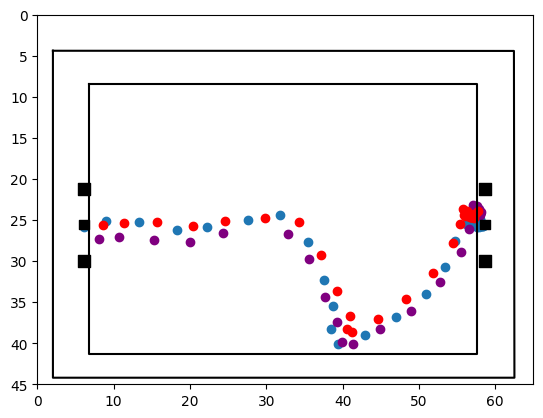

In [86]:
trial = df.sample(1)
fig,axis = plt.subplots(1
                        )


for ind,row in trial.iterrows():
    #axis.scatter(row['led_x_cm'][::15],row['led_y_cm'][::15],c ='k')
    #axis.scatter(row['camera_1_x_cm'][::15],row['camera_1_y_cm'][::15])
    #axis.scatter(row['camera_2_x_cm'][::15],row['camera_2_y_cm'][::15])
    #axis.scatter(row['camera_3_x_cm'][::15],row['camera_3_y_cm'][::15])
    head_cen_x = np.nanmedian([row['led_x_cm'].astype(float),row['camera_1_x_cm'].astype(float),
                               row['camera_2_x_cm'].astype(float),row['camera_3_x_cm'].astype(float)],0)
    
    head_cen_y = np.nanmedian([row['led_y_cm'].astype(float),row['camera_1_y_cm'].astype(float),
                               row['camera_2_y_cm'].astype(float),row['camera_3_y_cm'].astype(float)],0)
    axis.scatter(head_cen_x[::15],head_cen_y[::15])

    axis.scatter(row['leftear_x_cm'][::15],row['leftear_y_cm'][::15],c = 'purple')
    axis.scatter(row['rightear_x_cm'][::15],row['rightear_y_cm'][::15],c = 'red')

    
    plot_arena(trial,axis,bottom=True)
    #axis.scatter(row['leftportT_x_cm'],row['leftportT_y_cm'],c = 'k')
    #axis.scatter(row['leftportB_x_cm'],row['leftportB_y_cm'],c = 'k')
#
    #
    #axis.scatter(row['rightportT_x_cm'],row['rightportT_y_cm'],c = 'k')
    #axis.scatter(row['rightportB_x_cm'],row['rightportB_y_cm'],c = 'k')
        
    #axis.scatter(row['leftspout_x_cm'],row['leftspout_y_cm'],c = 'k',s=100)
    #axis.scatter(row['rightspout_x_cm'],row['rightspout_y_cm'],c = 'k',s=100)





In [90]:
df1 = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\042525\F3LITT\oa_cam1\cluster_F3LITT_042525_oa.h5")



In [91]:
df1

,first_poke,second_poke,trial_timestamps,trial_vidframes,arenaTL_T_x,arenaTL_T_y,arenaTL_T_likelihood,arenaTR_T_x,arenaTR_T_y,arenaTR_T_likelihood,...,gt_obstacleBL_x_cm,gt_obstacleBL_y_cm,gt_obstacle_cen_x,gt_obstacle_cen_x_cm,gt_obstacle_cen_y,gt_obstacle_cen_y_cm,obstacle_cluster,mean_gt_obstacle_cen_x_cm,mean_gt_obstacle_cen_y_cm,cluster_label
0,44198.433830,44214.094336,"[44198.441331, 44198.457638, 44198.474252, 441...","[237, 238, 239, 240, 241, 242, 243, 244, 245, ...",27.096758,53.866241,"[0.9920127987861633, 0.9929288029670715, 0.992...",840.144958,56.099207,"[0.994195282459259, 0.9956080317497253, 0.9926...",...,26.319582,20.864823,404.282745,30.092840,155.813743,11.598017,0,30.930302,11.653927,0.0
1,44214.094336,44224.302489,"[44214.0992, 44214.116224, 44214.132518, 44214...","[[1176, 1177, 1178, 1179, 1180, 1181, 1182, 11...",27.096758,53.866241,"[0.9840070605278015, 0.991772472858429, 0.9870...",840.144958,56.099207,"[0.9926865100860596, 0.9788370132446289, 0.988...",...,26.313274,20.891008,404.056760,30.076019,155.727161,11.591572,0,30.930302,11.653927,0.0
2,44224.302489,44229.631833,"[44224.304627, 44224.321254, 44224.338496, 442...","[1788, 1789, 1790, 1791, 1792, 1793, 1794, 179...",27.096758,53.866241,"[0.9908022284507751, 0.9931229948997498, 0.993...",840.144958,56.099207,"[0.9911268353462219, 0.994124710559845, 0.9875...",...,26.327821,20.842813,404.334478,30.096691,155.713786,11.590576,0,30.930302,11.653927,0.0
3,44229.631833,44244.124838,"[44229.641177, 44229.657395, 44229.674099, 442...","[[2108, 2109, 2110, 2111, 2112, 2113, 2114, 21...",27.096758,53.866241,"[0.9928881525993347, 0.9911689758300781, 0.989...",840.144958,56.099207,"[0.9934710264205933, 0.9899383783340454, 0.991...",...,26.311577,20.902201,404.132639,30.081667,155.916054,11.605632,0,30.930302,11.653927,0.0
4,44244.124838,44253.792281,"[44244.131763, 44244.14839, 44244.165696, 4424...","[2977, 2978, 2979, 2980, 2981, 2982, 2983, 298...",27.096758,53.866241,"[0.9870015382766724, 0.9913275837898254, 0.992...",840.144958,56.099207,"[0.9946203231811523, 0.9957329630851746, 0.995...",...,25.557551,45.877981,391.242882,29.122216,486.600924,36.220204,2,29.589587,36.088219,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,45484.819110,45494.908492,"[45484.820864, 45484.837516, 45484.854156, 454...","[[77379, 77380, 77381, 77382, 77383, 77384, 77...",27.096758,53.866241,"[0.9902166128158569, 0.9900699257850647, 0.987...",840.144958,56.099207,"[0.9940639138221741, 0.9942582845687866, 0.996...",...,28.193502,20.774948,429.992217,32.006528,154.738670,11.517993,0,30.930302,11.653927,0.0
61,45494.908492,45534.991577,"[45494.909491, 45494.926208, 45494.943462, 454...","[77984, 77985, 77986, 77987, 77988, 77989, 779...",27.096758,53.866241,"[0.9905277490615845, 0.9927940964698792, 0.991...",840.144958,56.099207,"[0.9931496977806091, 0.9957906603813171, 0.995...",...,28.191845,20.781037,429.992372,32.006539,155.352019,11.563648,0,30.930302,11.653927,0.0
62,45534.991577,45547.313433,"[45534.99822, 45535.014464, 45535.030694, 4553...","[[80388, 80389, 80390, 80391, 80392, 80393, 80...",27.096758,53.866241,"[0.9890311360359192, 0.9878442287445068, 0.986...",840.144958,56.099207,"[0.9949843883514404, 0.994679868221283, 0.9945...",...,28.194217,20.784819,429.809370,31.992918,155.232100,11.554722,0,30.930302,11.653927,0.0
63,45547.313433,45573.001804,"[45547.320588, 45547.337228, 45547.353856, 455...","[81127, 81128, 81129, 81130, 81131, 81132, 811...",27.096758,53.866241,"[0.9912075400352478, 0.9865793585777283, 0.989...",840.144958,56.099207,"[0.9932975172996521, 0.9938494563102722, 0.995...",...,26.844099,45.850361,403.609445,30.042723,483.693381,36.003781,2,29.589587,36.088219,2.0


2.0


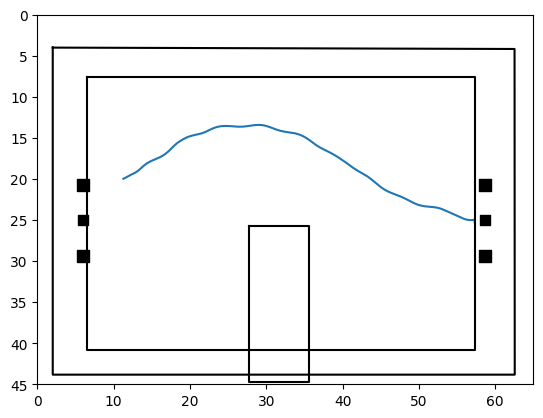

In [118]:
trial = df1.sample(1)


for ind,row in trial.iterrows():
    fig,axis = plt.subplots(1)
    axis.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm)   

    
    plot_arena(trial,axis,bottom=True)
    obstacle_x = [row.gt_obstacleTL_x_cm,
        row.gt_obstacleTR_x_cm,row.gt_obstacleTR_x_cm,
        row.gt_obstacleTL_x_cm,
        row.gt_obstacleTL_x_cm]
    obstacle_y = [row.gt_obstacleTL_y_cm,
        row.gt_obstacleTL_y_cm,row.gt_obstacleBL_y_cm,
        row.gt_obstacleBL_y_cm,
        row.gt_obstacleTL_y_cm]
    
    axis.plot([obstacle_x[0],obstacle_x[1],obstacle_x[2],obstacle_x[3],obstacle_x[0]],
                              [obstacle_y[0],obstacle_y[1],obstacle_y[2],obstacle_y[3],obstacle_y[0]],c='k')
    print(row.cluster_label)


(0.0, 61.0)

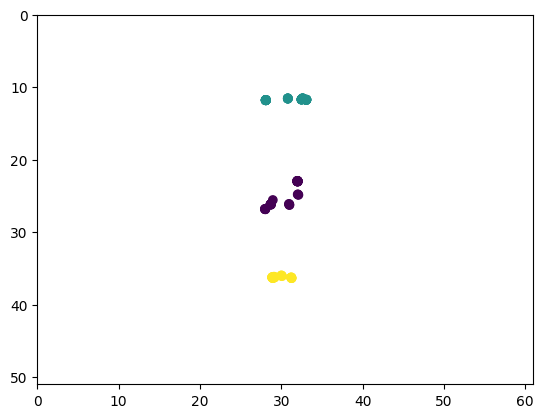

In [13]:
df1 = df1[df1['gt_obstacle_cen_x_cm'].notna()]
kmeans_input = np.vstack([df1['gt_obstacle_cen_x_cm'].values, df1['gt_obstacle_cen_y_cm'].values])
kmeans_input = np.transpose(kmeans_input).astype((float))
labels = KMeans(n_clusters=3).fit(kmeans_input).labels_
df1['obstacle_cluster'] = labels




plt.scatter(df1['gt_obstacle_cen_x_cm'], df1['gt_obstacle_cen_y_cm'], c=labels)
plt.ylim([51,0]); plt.xlim([0, 61])

In [67]:
labels

0      2.0
1      2.0
2      2.0
3      2.0
4      1.0
      ... 
119    0.0
120    0.0
121    0.0
122    0.0
123    0.0
Name: cluster_label, Length: 123, dtype: float64

(0.0, 61.0)

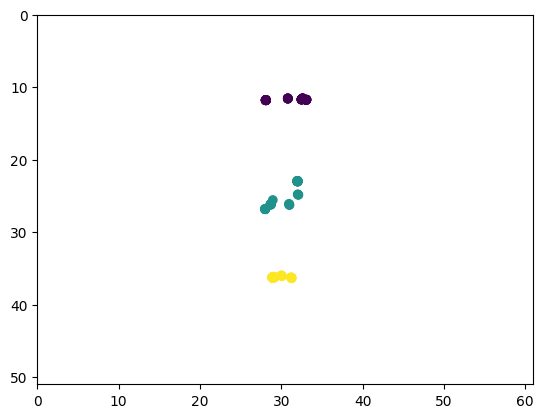

In [66]:
labels = df1['cluster_label']
plt.scatter(df1['gt_obstacle_cen_x_cm'], df1['gt_obstacle_cen_y_cm'], c=labels)
plt.ylim([51,0]); plt.xlim([0, 61])

In [65]:
test = df1[df1['gt_obstacle_cen_x_cm'].notna()]
numcluster = 3

kmeans_input = np.vstack([df1['gt_obstacle_cen_x_cm'].values, df1['gt_obstacle_cen_y_cm'].values])
kmeans_input = np.transpose(kmeans_input)
labels = KMeans(n_clusters=numcluster).fit(kmeans_input).labels_
df1['obstacle_cluster'] = labels
#get mean of obstacle center
for clusters, cluster_name in enumerate(df1['obstacle_cluster'].unique()):
    x=df1.loc[df1['obstacle_cluster']==cluster_name]
    mean_cenx = np.nanmean(x['gt_obstacle_cen_x_cm'])
    mean_ceny = np.nanmean(x['gt_obstacle_cen_y_cm'])

    for ind,row in df1.iterrows(): 
        if row['obstacle_cluster'] == cluster_name:
            df1.at[ind,'mean_gt_obstacle_cen_x_cm'] = mean_cenx
            df1.at[ind,'mean_gt_obstacle_cen_y_cm'] = mean_ceny
#label cluster by position 
if numcluster == 3:
    print(numcluster)
    df1['cluster_label'] = np.nan
    x_pos,y_pos  = np.sort(df1['mean_gt_obstacle_cen_x_cm'].unique()),np.sort(df1['mean_gt_obstacle_cen_y_cm'].unique())
    
    row_1, row_2, row_3 = y_pos[0],y_pos[1],y_pos[2]
    for clusters, cluster_name in enumerate(df1['obstacle_cluster'].unique()):
        #label cluster by obstacle post
        x=df1.loc[df1['obstacle_cluster']==cluster_name]
        for ind,row in x.iterrows():
            closest = find_closest_numpy(row['mean_gt_obstacle_cen_y_cm'], y_pos)
            if closest == 0:
                df1.at[ind,'cluster_label'] = 0
            if closest == 1:
                df1.at[ind,'cluster_label'] = 1
            if closest == 2:
                df1.at[ind,'cluster_label'] = 2
                

3


In [58]:
import numpy as np

def find_closest_numpy(target, values):
    values_array  =values
    index = np.argmin(np.abs(values_array - target))
    return index

# Example usage:
closest = find_closest_numpy(row['mean_gt_obstacle_cen_y_cm'], y_pos)

In [60]:
y_pos


array([11.72034702, 24.67292195, 36.23541226])

In [59]:
closest

2

In [53]:
row['mean_gt_obstacle_cen_y_cm']

36.23541225906896

In [45]:
test1 = cluster_obstacle(df1,3)

3


TypeError: argument of type 'numpy.float64' is not iterable

In [41]:
for clusters, cluster_name in enumerate(df1['obstacle_cluster'].unique()):
    x=df1.loc[df1['obstacle_cluster']==cluster_name]
    mean_cenx = np.nanmean(x['gt_obstacle_cen_x_cm'])
    mean_ceny = np.nanmean(x['gt_obstacle_cen_y_cm'])

    for ind,row in df1.iterrows(): 
        if row['obstacle_cluster'] == cluster_name:
            df1.at[ind,'mean_gt_obstacle_cen_x_cm'] = mean_cenx
            df1.at[ind,'mean_gt_obstacle_cen_y_cm'] = mean_ceny
x_pos,y_pos  = np.sort(df1['mean_gt_obstacle_cen_x_cm'].unique()),np.sort(df1['mean_gt_obstacle_cen_y_cm'].unique())
  

In [42]:
x_pos

array([29.70347839, 30.3566504 , 30.64666815])

In [43]:
y_pos

array([11.72034702, 24.67292195, 36.23541226])

In [ ]:
# k means of pillar postion 
kmeans_input = np.stack([df1['gt_obstacle_cen_x_cm'].map(np.nanmean), df1['gt_obstacle_cen_y_cm'].map(np.nanmean)])
kmeans_mask = np.any(np.isnan(kmeans_input), axis=0)
kmeans_input = kmeans_input[:,~kmeans_mask]

# plot cluster postions
cluster_label = df1['obstacle_cluster'].tolist()

plt.figure()
for i in range(len(df1['obstacle_cluster'])):
    obstacles = kmeans_input[:,i]
    plt.plot(obstacles[0], obstacles[1], '*',color=list(mcolors.TABLEAU_COLORS)[cluster_label[i]])
    plt.ylim([20.03, 0]); plt.xlim([0, 33.30])

In [44]:
def cluster_obstacle(df,numcluster):

    """cluster obstacle position"""
    df = df[df['gt_obstacle_cen_x_cm'].notna()]


    kmeans_input = np.vstack([df['gt_obstacle_cen_x_cm'].values, df['gt_obstacle_cen_y_cm'].values])

    kmeans_input = np.transpose(kmeans_input)

    labels = KMeans(n_clusters=numcluster).fit(kmeans_input).labels_
    df['obstacle_cluster'] = labels

    #get mean of obstacle center
    for clusters, cluster_name in enumerate(df['obstacle_cluster'].unique()):
        x=df.loc[df['obstacle_cluster']==cluster_name]
        mean_cenx = np.nanmean(x['gt_obstacle_cen_x_cm'])
        mean_ceny = np.nanmean(x['gt_obstacle_cen_y_cm'])
  
        for ind,row in df.iterrows(): 
            if row['obstacle_cluster'] == cluster_name:
                df.at[ind,'mean_gt_obstacle_cen_x_cm'] = mean_cenx
                df.at[ind,'mean_gt_obstacle_cen_y_cm'] = mean_ceny
    #label cluster by position 
    if numcluster == 3:
        print(numcluster)
        df['cluster_label'] = np.nan
        x_pos,y_pos  = np.sort(df['mean_gt_obstacle_cen_x_cm'].unique()),np.sort(df['mean_gt_obstacle_cen_y_cm'].unique())
        
        row_1, row_2, row_3 = y_pos[0],y_pos[1],y_pos[2]
        for clusters, cluster_name in enumerate(df['obstacle_cluster'].unique()):
            #label cluster by obstacle post
            x=df.loc[df['obstacle_cluster']==cluster_name]
            for ind,row in x.iterrows():
                if row['mean_gt_obstacle_cen_y_cm'] in row_1: 
                     df.at[ind,'cluster_label'] = 0

                if row['mean_gt_obstacle_cen_y_cm'] in row_2:
                    df.at[ind,'cluster_label'] = 1

                if row['mean_gt_obstacle_cen_y_cm'] in row_3:
                    df.at[ind,'cluster_label'] = 2

             
    elif numcluster == 6:
        print(numcluster)
        df['cluster_label'] = np.nan
        x_pos,y_pos  = np.sort(df['mean_gt_obstacle_cen_x_cm'].unique()),np.sort(df['mean_gt_obstacle_cen_y_cm'].unique())
        col_1, col_2 = x_pos[0:3],x_pos[3:6]
        row_1, row_2, row_3 = y_pos[0:2],y_pos[2:4],y_pos[4:6]
        for clusters, cluster_name in enumerate(df['obstacle_cluster'].unique()):
            #label cluster by obstacle post
            x=df.loc[df['obstacle_cluster']==cluster_name]
            for ind,row in x.iterrows():
                if row['mean_gt_obstacle_cen_x_cm'] in col_1 and row['mean_gt_obstacle_cen_y_cm'] in row_1: 
                     df.at[ind,'cluster_label'] = 0

                if row['mean_gt_obstacle_cen_x_cm'] in col_2 and row['mean_gt_obstacle_cen_y_cm'] in row_1:
                    df.at[ind,'cluster_label'] = 1

                #if row['mean_gt_obstacle_cen_x_cm'] in col_3 and row['mean_gt_obstacle_cen_y_cm'] in row_1:
                 #   df.at[ind,'cluster_label'] = 2

                if row['mean_gt_obstacle_cen_x_cm'] in col_1 and row['mean_gt_obstacle_cen_y_cm'] in row_2:
                    df.at[ind,'cluster_label'] = 2

                if row['mean_gt_obstacle_cen_x_cm'] in col_2 and row['mean_gt_obstacle_cen_y_cm'] in row_2:
                    df.at[ind,'cluster_label'] = 3

                #if row['mean_gt_obstacle_cen_x_cm'] in col_3 and row['mean_gt_obstacle_cen_y_cm'] in row_2:
                    #df.at[ind,'cluster_label'] = 5

                if row['mean_gt_obstacle_cen_x_cm'] in col_1 and row['mean_gt_obstacle_cen_y_cm'] in row_3:
                    df.at[ind,'cluster_label'] = 4

                if row['mean_gt_obstacle_cen_x_cm'] in col_2 and row['mean_gt_obstacle_cen_y_cm'] in row_3:
                    df.at[ind,'cluster_label'] = 5

            
           #    df.at[ind,'cluster_label'] = 8
    df['obstacle_cluster'] = df['cluster_label'].astype(int)
    return df

In [ ]:
x_pos,y_pos  = np.sort(df['mean_gt_obstacle_cen_x_cm'].unique()),np.sort(df['mean_gt_obstacle_cen_y_cm'].unique())

In [ ]:
columns_list

In [106]:
for ind, row in df.iterrows():
    for i in arena_list:
        df.at[ind,i] = np.nanmedian(row[i],0)


In [120]:
df.arenaTL_T_x_cm

0     [1.9002642573923094, 1.8752689783627863, 1.797...
1     [1.9427296170718946, 1.9071024325295232, 1.773...
2     [2.143051745763889, 2.1006100372369816, 2.0195...
3     [2.082285095646753, 2.0961180279500544, 2.1021...
4     [1.9398893415981922, 1.931325344699606, 1.9856...
                            ...                        
58    [2.0544847329188975, 2.062091000610851, 2.0325...
59    [1.9026540211505443, 1.8415992828965724, 1.917...
60    [2.145084747556428, 1.9564108115583165, 2.0326...
61    [1.8974738488067833, 1.781364498761043, 1.8535...
62    [2.2015721062839146, 2.182287868241996, 2.1591...
Name: arenaTL_T_x_cm, Length: 63, dtype: object

In [ ]:
arena_top_x = 
arena_top_y =

arena_bottom_x =
arena_bottom_y = 



In [46]:
def gather_all_sessions(path,dates_list):
        data_dict = {'date': [],
                    'animal': [],
                    'task': [],             
                    'poke1_ts':[],
                    'poke2_ts': [],
                    'TOP1_ts': [],
                    'poke1_t0':[],
                    'poke2_t0': [],
                    'TOP1_t0': [],
                    'condition':[]}
        # list of dates for analysis
        data_path = Path(path).expanduser()
        # populate dict with metadata and timestamps
        for date in dates_list:
            use_animals = [k for k,v in metadata[date].items()]
            for ani in use_animals:
                for task in os.listdir(data_path / date / ani):
                    data_paths = [str(i) for i in list((data_path / date / ani/ task).rglob('*.csv'))]
                    data_paths = [i for i in data_paths if 'spout' not in i]
                    data_paths = [i for i in data_paths if 'REYE' not in i]
                    data_paths = [i for i in data_paths if 'Ephys' not in i]
                    data_paths = [i for i in data_paths if 'WORLD' not in i]
                   
                    if data_paths != []:
                        _, name = os.path.split(data_paths[1])
                        split_name = name.split('_')
                        
                        data_dict['date'].append(split_name[0])
                        data_dict['animal'].append(split_name[1])
                        data_dict['task'].append(split_name[4])
                        data_dict['condition'].append(split_name[2])
                    for ind, csv in enumerate(data_paths):
                        timestamp_path = csv
                        #print(csv,split_name,name)
                        time = read_timestamp_file(timestamp_path)
                        _, name = os.path.split(data_paths[ind])
                        split_name = name.split('_')
                        print(split_name)
                        data_dict[split_name[6] +'_ts'].append(time)
                        data_dict[split_name[6] +'_t0'].append(time[0])
        
        all_sessions = pd.DataFrame.from_dict(data_dict)
        return all_sessions

In [14]:
def read_timestamp_file(timestamp_path,position_data_length=None,
                        force_timestamp_shift=False):
    """ Read timestamps from a .csv file.

    Parameters
    ----------
    position_data_length : None or int
        Number of timesteps in data from deeplabcut. This is used to
        determine whether or not the number of timestamps is too short
        for the number of video frames.
        Eyecam and Worldcam will have half the number of timestamps as
        the number of frames, since they are aquired as an interlaced
        video and deinterlaced in analysis. To fix this, timestamps need
        to be interpolated.
    force_timestamp_shift : bool
        When True, the timestamps will be interpolated regardless of
        whether or not the number of timestamps is too short for the
        number of frames. Default is False.

    Returns
    -------
    camT : np.array
        Timestamps of camera interpolated so that there are twice the
        number of timestamps in the array than there were in the provided
        csv file.

    """

    # Read data and set up format
    s = pd.read_csv(timestamp_path, encoding='utf-8',
                    engine='c', header=None).squeeze()
    
    # If the csv file has a header name for the column, (which is
    # is the int 0 for some early recordings), remove it.
    if s[0] == 0:
        s = s[1:]
    
    # Read the timestamps as a series and format them
    camT = read_timestamp_series(s)
    
    # Auto check if vids were deinterlaced
    if position_data_length is not None:

        if position_data_length > len(camT):

            # If the number of timestamps is too short for the number
            # of frames, interpolate the timestamps.

            camT = interp_timestamps(camT, use_medstep=False)
    
    # Force the times to be shifted if the user is sure it should be done
    if force_timestamp_shift is True:

        camT = interp_timestamps(camT, use_medstep=False)
    
    return camT

In [15]:
def read_timestamp_series(s):
    """ Read timestamps as a pd.Series and format time.

    Parameters
    ----------
    s : pd.Series
        Timestamps as a Series. Expected to be formated as
        hours:minutes:seconds.microsecond

    Returns
    -------
    output_time : np.array
        Returned as the number of seconds that have passed since the
        previous midnight, with microescond precision, e.g. 700.000000

    """

    # Expected string format for timestamps.
    fmt = '%H:%M:%S.%f'

    output_time = []

    if s.dtype != np.float64:

        for current_time in s:

            str_time = str(current_time).strip()

            try:
                t = datetime.strptime(str_time, fmt)

            except ValueError as v:
                # If the string had unexpected characters (too much precision) for
                # one timepoint, drop the extra characters.

                ulr = len(v.args[0].partition('unconverted data remains: ')[2])
                
                if ulr:
                    str_time = str_time[:-ulr]
            
            try:
                output_time.append(
                        (datetime.strptime(str_time, '%H:%M:%S.%f')
                            - datetime.strptime('00:00:00.000000', '%H:%M:%S.%f')
                            ).total_seconds())

            except ValueError:
                output_time.append(np.nan)

        output_time = np.array(output_time)

    else:
        output_time = s.values

    return output_time

In [16]:
def interp_timestamps(camT, use_medstep=False):
    """ Interpolate timestamps for double the number of
    frames. Compensates for video deinterlacing.
    
    Parameters
    ----------
    camT : np.array
        Camera timestamps aquired at 30Hz
    use_medstep : bool
        When True, the median diff(camT) will be used as the timestep
        in interpolation. If False, the timestep between each frame
        will be used instead.

    Returns
    -------
    camT_out : np.array
        Timestamps of camera interpolated so that there are twice the
        number of timestamps in the array. Each timestamp in camT will
        be replaced by two, set equal distances from the original.

    """

    camT_out = np.zeros(np.size(camT, 0)*2)
    medstep = np.nanmedian(np.diff(camT, axis=0))

    if use_medstep:
        
        # Shift each deinterlaced frame by 0.5 frame periods
        # forward/backwards assuming a constant framerate

        camT_out[::2] = camT - 0.25 * medstep
        camT_out[1::2] = camT + 0.25 * medstep
    
    elif not use_medstep:

        # Shift each deinterlaced frame by the actual time between
        # frames. If a camera frame was dropped, this approach will
        # be more accurate than `medstep` above.
        
        steps = np.diff(camT, axis=0, append=camT[-1]+medstep)
        camT_out[::2] = camT
        camT_out[1::2] = camT + 0.5 * steps

    return camT_out

In [127]:
string = 'oa'
target = 'cam'

if target not in string:
    print('no cam')

no cam


In [1]:
def deinterlace(vidfile, savepath, exp_fps=30, quiet=True):
        """ Deinterlace a video.

        Parameters
        ----------
        path : str
            Path to the video file.
        savepath : str
            Path to save the new video file. Default is None.
        rotate : bool
            Whether to rotate the video 180 degrees. Default is True.
        exp_fps : int
            Expected frame rate of the video. If the video matches
            this frame rate (in Hz), it will be deinterlaced. Otherwise,
            it will be skipped. Default is 30 Hz.
        quiet : bool
            Whether to suppress the output from ffmpeg. Default is True.

        Returns
        -------
        savepath : str
            Path to the new video file.

        """

        # Open video, get frame count and rate
        cap = cv2.VideoCapture(vidfile)
        fps = cap.get(cv2.CAP_PROP_FPS)

        # Skip this video if it doesn't match the expected frame rate.
        if fps != exp_fps:
            return

        # Create the FFMPEG commands for video rotation.
        vf_val = 'yadif=1:-1:, scale=640:480'

        print(os.path.normpath(vidfile))
        print(os.path.normpath(savepath))

        # Create the full FFMPEG command
        cmd = ['ffmpeg', '-i', os.path.normpath(vidfile), '-vf', vf_val, '-c:v', 'libx264',
              '-preset', 'slow', '-crf', '19', '-c:a', 'aac', '-b:a',
              '256k', '-y', os.path.normpath(savepath)]

        # Set the log level
        if quiet is True:
            cmd.extend(['-loglevel', 'quiet'])

        # Run the FFMPEG command.
        subprocess.run(cmd, capture_output=True, text=True)

        return savepath


In [2]:
REYE_vid = ['\\\\goeppert\\Vol2\\mike\\recordings\\050825\\F3LILT\\oa_cam1\\050825_F3LILT_control_Rig2_oa_cam1_REYE.avi']

In [4]:
REYE_vid[0]

'\\\\goeppert\\Vol2\\mike\\recordings\\050825\\F3LILT\\oa_cam1\\050825_F3LILT_control_Rig2_oa_cam1_REYE.avi'

In [5]:
avi_out_path = r'\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_control_Rig2_oa_cam1_REYEdeinter.avi'

In [11]:
import cv2
import os
import subprocess

In [13]:
os.path.exists(REYE_vid[0])

True

In [12]:
deinterlace(REYE_vid[0], avi_out_path, exp_fps=30, quiet=True)

\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_control_Rig2_oa_cam1_REYE.avi
\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_control_Rig2_oa_cam1_REYEdeinter.avi


FileNotFoundError: [WinError 2] The system cannot find the file specified